In [ ]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d doshiharmish/311servicerequestboston2021

Dataset URL: https://www.kaggle.com/datasets/doshiharmish/311servicerequestboston2021
License(s): ODC Public Domain Dedication and Licence (PDDL)
  0% 0.00/20.3M [00:00<?, ?B/s]
100% 20.3M/20.3M [00:00<00:00, 1.25GB/s]


In [ ]:
!unzip -q 311servicerequestboston2021.zip

In [ ]:
import pandas as pd

df = pd.read_csv("og_311_ServiceRequest_2021.csv", low_memory=False)
df.head()

,case_enquiry_id,open_dt,target_dt,closed_dt,ontime,case_status,closure_reason,case_title,subject,reason,...,police_district,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,source
0,101003578872,2021-01-01 00:06:37,2021-01-06 08:30:00,2021-01-01 05:36:42,ONTIME,Closed,Case Closed. Closed date : Fri Jan 01 05:36:42...,Improper Storage of Trash (Barrels),Public Works Department,Code Enforcement,...,C11,Dorchester,5,Ward 7,0709,797 Columbia Rd,2125.0,42.3202,-71.0572,Citizens Connect App
1,101003578875,2021-01-01 00:15:47,2021-01-05 08:30:00,2021-01-02 12:49:26,ONTIME,Closed,Case Closed. Closed date : 2021-01-02 12:49:26...,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,...,D14,Allston / Brighton,15,Ward 22,2211,50 Newton St,2135.0,42.3569,-71.1650,Citizens Connect App
2,101003578879,2021-01-01 00:26:46,NaN,2021-01-04 13:56:41,ONTIME,Closed,Case Closed. Closed date : 2021-01-04 13:56:41...,Notification,Mayor's 24 Hour Hotline,Notification,...,B2,Dorchester,13,13,1305,693 Dudley St,2125.0,42.3594,-71.0587,Constituent Call
3,101003578880,2021-01-01 00:27:00,NaN,2021-03-18 03:02:40,ONTIME,Closed,Case Closed Case Noted,Fire,Mayor's 24 Hour Hotline,Notification,...,B2,Dorchester,13,7,0710,INTERSECTION Nonquit St & Dudley St,NaN,42.3594,-71.0587,Constituent Call
4,101003578881,2021-01-01 00:36:34,2021-01-07 08:30:00,2021-01-01 05:43:25,ONTIME,Closed,Case Closed. Closed date : Fri Jan 01 05:43:25...,Poor Conditions of Property,Public Works Department,Code Enforcement,...,C11,Dorchester,7,Ward 13,1306,83-93 Stoughton St,2125.0,42.3157,-71.0623,Citizens Connect App


In [ ]:
df.columns

Index(['case_enquiry_id', 'open_dt', 'target_dt', 'closed_dt', 'ontime',
       'case_status', 'closure_reason', 'case_title', 'subject', 'reason',
       'type', 'queue', 'department', 'submittedphoto', 'closedphoto',
       'location', 'fire_district', 'pwd_district', 'city_council_district',
       'police_district', 'neighborhood', 'neighborhood_services_district',
       'ward', 'precinct', 'location_street_name', 'location_zipcode',
       'latitude', 'longitude', 'source'],
      dtype='object')

In [ ]:
df = df[[
    "case_title",
    "subject",
    "closure_reason",
    "open_dt",
    "department",
    "latitude",
    "longitude",
    "case_status"
]]

print(df.shape)



(273951, 8)


In [ ]:
df["complaint_text"] = (
    df["case_title"].astype(str) + " " +
    df["subject"].astype(str) + " " +
    df["closure_reason"].astype(str)
)

df = df.dropna(subset=["complaint_text"])
print("After text merge:", df.shape)



After text merge: (273951, 9)


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["complaint_text"].apply(clean_text)


In [ ]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity < -0.1:
        return "negative"
    elif polarity > 0.1:
        return "positive"
    else:
        return "neutral"

df["sentiment"] = df["clean_text"].apply(get_sentiment)
df["sentiment"].value_counts()

,count
sentiment,
neutral,243050
negative,23353
positive,7548


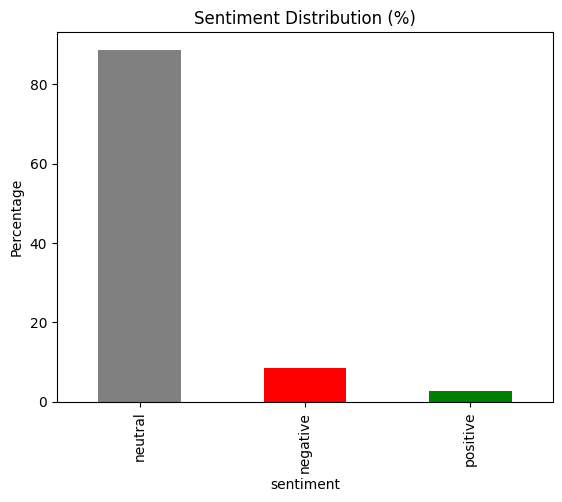

In [ ]:
(df["sentiment"].value_counts(normalize=True) * 100).plot(
    kind="bar",
    color=["gray", "red", "green"]
)

plt.title("Sentiment Distribution (%)")
plt.ylabel("Percentage")
plt.show()

In [ ]:
le = LabelEncoder()
df["sentiment_label"] = le.fit_transform(df["sentiment"])

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.9
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment_label"]

In [ ]:
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

print("Before balancing:", np.bincount(y))
print("After balancing:", np.bincount(y_bal))

Before balancing: [ 23353 243050   7548]
After balancing: [243050 243050 243050]


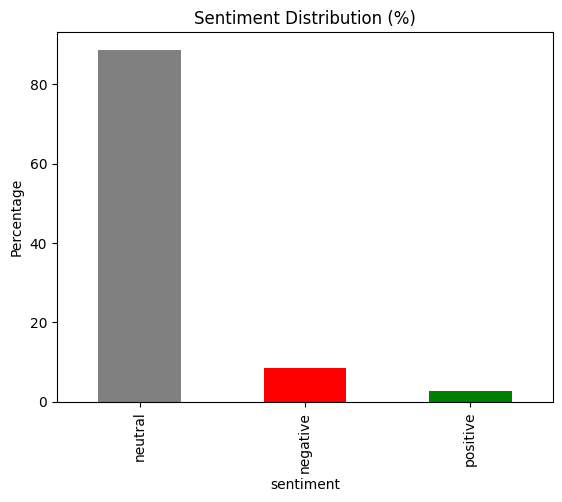

In [ ]:
(df["sentiment"].value_counts(normalize=True) * 100).plot(
    kind="bar",
    color=["gray", "red", "green"]
)

plt.title("Sentiment Distribution (%)")
plt.ylabel("Percentage")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, n_jobs=-1)

In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print(classification_report(
    y_test, y_pred, target_names=le.classes_
))

Accuracy: 0.9890626071453061
              precision    recall  f1-score   support

    negative       0.99      0.99      0.99     48431
     neutral       0.99      0.98      0.98     48639
    positive       0.99      1.00      0.99     48760

    accuracy                           0.99    145830
   macro avg       0.99      0.99      0.99    145830
weighted avg       0.99      0.99      0.99    145830



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_bal,
    y_bal,
    cv=5,
    scoring="accuracy"
)

print("Cross-val accuracy:", scores.mean())


Cross-val accuracy: 0.9818171843927861


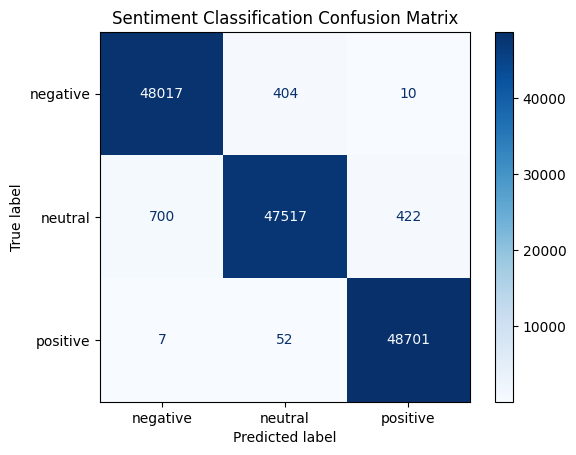

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=le.classes_,
    cmap="Blues"
)
plt.title("Sentiment Classification Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(model, "complaint_ml_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("✅ Model & vectorizer saved")

✅ Model & vectorizer saved


In [ ]:

model = joblib.load("complaint_ml_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

sample_text = ["Road is damaged badly and causing accidents"]

sample_clean = [clean_text(sample_text[0])]
sample_vec = vectorizer.transform(sample_clean)

pred = model.predict(sample_vec)
print("Prediction:", le.inverse_transform(pred)[0])

Prediction: negative


In [ ]:
!ls

311servicerequestboston2021.zip  label_encoder.pkl
Boston_Neighborhoods.geojson	 og_311_ServiceRequest_2021.csv
complaint_ml_model.pkl		 sample_data
kaggle.json			 tfidf_vectorizer.pkl
